In [1]:
import numpy as np
import pandas as pd
import os, re, math, platform
from pathlib import Path
import matplotlib.pyplot as plt
import json
import joblib
from scipy.stats import randint as sp_randint
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, auc, fbeta_score
from imblearn.metrics import geometric_mean_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
from xgboost import plot_importance
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,ExtraTreesClassifier,AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
#from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
from matplotlib import pyplot
from sklearn.metrics import matthews_corrcoef, confusion_matrix,precision_recall_curve, roc_curve, auc, fbeta_score,roc_auc_score
from fea_extract import read_fasta,insert_AAC,insert_DPC,insert_CKSAAGP,insert_CTD,insert_PAAC,insert_AAI,insert_GTPC,insert_QSO,insert_AAE,insert_PSAAC,insert_word2int,insert_ASDC
import warnings 
from collections import Counter
from tools import cv,evaluate
import matplotlib.pyplot as plt
import seaborn as sns
Path('./results/balance_eval_AUC/').mkdir(exist_ok=True,parents=True)
warnings.filterwarnings('ignore')
seed=10

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID";
os.environ["CUDA_VISIBLE_DEVICES"] = "1";

In [3]:
#!pip install lightgbm
from sklearn.ensemble import BaggingClassifier

In [4]:
def pro_data(seq):
    df_n = insert_PAAC(seq)
    df_n = insert_AAC(df_n)
    df_n = insert_CKSAAGP(df_n)
    df_n = insert_CTD(df_n)
    df_n = insert_DPC(df_n)
    df_n = insert_GTPC(df_n)
    df_n = insert_QSO(df_n)
    df_n = insert_AAE(df_n)
    df_n = insert_ASDC(df_n)
    #df_n = insert_word2int(df_n)
    return df_n

In [5]:
seq_X_train = pd.read_csv('data/train/X_train.csv')
seq_X_test = pd.read_csv('data/test/X_test.csv')
seq_y_train = pd.read_csv('data/train/y_train.csv')
seq_y_test = pd.read_csv('data/test/y_test.csv')

In [6]:
Seq_X_train = pro_data(seq_X_train)
Seq_X_test = pro_data(seq_X_test)

In [7]:
Seq_X_train

,Id,Sequence,Xc1.A,Xc1.R,Xc1.N,Xc1.D,Xc1.C,Xc1.Q,Xc1.E,Xc1.G,...,ASDC_390,ASDC_391,ASDC_392,ASDC_393,ASDC_394,ASDC_395,ASDC_396,ASDC_397,ASDC_398,ASDC_399
0,Sequence_530,FWGALIKGAAKLIPSVVGLFKKKQ,0.871008,0.000000,0.000000,0.000000,0.000000,0.290336,0.000000,0.871008,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,seq_1416,VILIFVKKKAAKPYRQVLRNIYRHIRPKMR,0.468778,1.171944,0.234389,0.000000,0.000000,0.234389,0.000000,0.000000,...,0.004598,0.002299,0.004598,0.002299,0.018391,0.000000,0.000000,0.002299,0.000000,0.002299
2,Sequence_366,FLFRVASKVFPALIGKFKKK,0.501838,0.250919,0.000000,0.000000,0.000000,0.000000,0.000000,0.250919,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,seq_1019,VILIFVKKKAAKPYRQVLRNIYRHIRPKMW,0.465773,0.931546,0.232887,0.000000,0.000000,0.232887,0.000000,0.000000,...,0.004598,0.002299,0.004598,0.002299,0.013793,0.000000,0.000000,0.002299,0.004598,0.002299
4,seq_1147,VILIFVKKKAAKPLRQFMRNIYRHWRPKMK,0.479904,0.959809,0.239952,0.000000,0.000000,0.239952,0.000000,0.000000,...,0.002299,0.000000,0.002299,0.000000,0.004598,0.000000,0.000000,0.000000,0.002299,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1855,Sequence_271,TVTITDVGPNSLAGVPAEASEPSVSQSPVS,1.426365,0.000000,0.475455,0.475455,0.000000,0.475455,0.950910,0.950910,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1856,Sequence_222,RFQACRFGLAGEYVDPATGN,0.775888,0.517259,0.258629,0.258629,0.258629,0.258629,0.258629,0.775888,...,0.000000,0.005263,0.005263,0.000000,0.000000,0.000000,0.005263,0.005263,0.000000,0.000000
1857,Sequence_431,EYSLFPGQVVIMEGINTTGRKLVATKLYEG,0.289049,0.289049,0.289049,0.000000,0.000000,0.289049,0.867147,1.156196,...,0.002299,0.002299,0.002299,0.002299,0.002299,0.002299,0.006897,0.006897,0.000000,0.002299
1858,Sequence_16,KPFLMPVEDVFTITGRGTVATGRI,0.282604,0.565208,0.000000,0.282604,0.000000,0.000000,0.282604,0.847812,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
Seq_X_test

,Id,Sequence,Xc1.A,Xc1.R,Xc1.N,Xc1.D,Xc1.C,Xc1.Q,Xc1.E,Xc1.G,...,ASDC_390,ASDC_391,ASDC_392,ASDC_393,ASDC_394,ASDC_395,ASDC_396,ASDC_397,ASDC_398,ASDC_399
0,Sequence_160,GCASRCKAKCAGRRCKGWASASFRGRCYCKCFRC,1.059835,1.271802,0.000000,0.000000,1.695736,0.000000,0.000000,0.847868,...,0.000000,0.000000,0.000000,0.000000,0.001783,0.000000,0.000000,0.000000,0.000000,0.000000
1,seq_763,VILIFVKKKAAKPYRQVYRNIYRNWRPKWW,0.445261,0.890522,0.445261,0.000000,0.000000,0.222630,0.000000,0.000000,...,0.000000,0.011494,0.006897,0.002299,0.020690,0.000000,0.000000,0.002299,0.020690,0.006897
2,Sequence_122,GVIPCGESCVFIPCISSVLGCSCKNKVCYRD,0.000000,0.382820,0.382820,0.382820,2.296921,0.000000,0.382820,1.148461,...,0.000000,0.000000,0.000000,0.000000,0.002151,0.000000,0.000000,0.000000,0.000000,0.000000
3,seq_1337,VMLIFVKKKAAKPLRQVLRNIYRHWRPRWW,0.443482,1.108706,0.221741,0.000000,0.000000,0.221741,0.000000,0.000000,...,0.000000,0.000000,0.002299,0.000000,0.006897,0.000000,0.000000,0.000000,0.006897,0.000000
4,seq_570,VILIFVKKKAAKPLRQVMRNIYRHWRPKMK,0.482649,0.965298,0.241324,0.000000,0.000000,0.241324,0.000000,0.000000,...,0.002299,0.000000,0.002299,0.000000,0.004598,0.000000,0.000000,0.000000,0.002299,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,Sequence_527,QTKPRGDRARYLKLARTNAATALTSKLSQQSTVHQRLTALAS,2.134689,1.524778,0.304956,0.304956,0.000000,1.219822,0.000000,0.304956,...,0.000000,0.001161,0.000000,0.003484,0.002323,0.004646,0.005807,0.001161,0.000000,0.000000
462,Sequence_636,VHKFEHWLNQLKVAPLITKIRNYADEIREYQLEKLFNQMPYLNEK,0.573424,0.573424,1.146848,0.286712,0.000000,0.860136,1.433561,0.000000,...,0.002020,0.005051,0.002020,0.004040,0.001010,0.000000,0.000000,0.000000,0.000000,0.003030
463,Sequence_757,VQGSRLNSQPACTARRRTRVLIL,0.548694,1.371734,0.274347,0.000000,0.274347,0.548694,0.000000,0.274347,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
464,Sequence_7,YAGFSADCRPRSRPSSDSCSVPMTGARGQGL,0.899335,1.199114,0.000000,0.599557,0.599557,0.299778,0.000000,1.199114,...,0.002151,0.000000,0.006452,0.002151,0.008602,0.012903,0.002151,0.002151,0.000000,0.000000


In [9]:
Seq_X_train.to_csv('data/train/Seq_X_train_all.csv',index=False)
Seq_X_test.to_csv('data/test/Seq_X_test_all.csv',index=False)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from mlxtend.classifier import StackingClassifier

from sklearn.svm import LinearSVC

#ml = ["DT","LGBM","XGBoost","RF","ET","GBDT","SVM","MLP","LR","AB","voting_clf","stacking","Two_eclf"]
ml = ["DT","ET"]
#layer_one= [  LGBMClassifier(random_state = seed),ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),MLPClassifier(hidden_layer_sizes=700,learning_rate="adaptive",random_state=seed)]
                     #('rf5',GaussianNB()),
#                   ('SVM', SVC(kernel='linear',probability=True))]
#layer_two = [SVC(random_state=seed,probability=True), ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),LGBMClassifier(random_state = seed)]
             #GaussianNB()]
#                   ('SVC', SVC(kernel='linear',probability=True))]

#layer_two_meta= StackingClassifier(classifiers = layer_one, meta_classifier=LogisticRegression())    
DT  = DecisionTreeClassifier(random_state=seed)
#LGBM = LGBMClassifier(random_state = seed)
#GBDT = GradientBoostingClassifier(random_state=seed)
ET = ExtraTreesClassifier(random_state=seed)
#SVM = SVC(random_state=seed,probability=True)
#MLP = MLPClassifier(hidden_layer_sizes=1000,learning_rate="adaptive",random_state=seed)
#RF = RandomForestClassifier(random_state=seed)
#XGBoost = XGBClassifier(random_state=seed)
#LR  = LogisticRegression(random_state=seed,solver='liblinear')
#AB = AdaBoostClassifier(random_state=seed)
#SDG_Classifier = SGDClassifier(max_iter=1000, tol=1e-3) 
#voting_clf = VotingClassifier(estimators = [('lgbm',LGBM),('rf',RF),('xgb',XGBoost),('ET',ET),('GBDT',GBDT)], voting = 'soft')
#Bagging_clf = BaggingClassifier(base_estimator=RandomForestClassifier(random_state=seed))
#VOT_STACK = StackingClassifier(classifiers = voting_clf, meta_classifier=LR)
#stacking = StackingClassifier(classifiers=[LGBM,RF,XGBoost,ET],meta_classifier=LR)
#Two_eclf = StackingClassifier(classifiers=layer_two, meta_classifier=layer_two_meta)

In [11]:
np.random.seed(42)
fea = Seq_X_train.columns[2:]
X_train = Seq_X_train[fea].to_numpy()
X_test = Seq_X_test[fea].to_numpy()
y_train = seq_y_train.to_numpy()
y_test = seq_y_test.to_numpy()

In [12]:
import joblib
index = []
ALL_eval=pd.DataFrame()
# Define the directory to save model weights
weights_dir = 'model_weights/'

for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))

    # Save model weights
    weights_path = os.path.join(weights_dir, '{}_weights.pkl'.format(i))
    joblib.dump(model, weights_path)
    
ALL_eval.columns = index

process_DT
process_ET


In [13]:
"""
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index
"""

'\nindex = []\nALL_eval=pd.DataFrame()\nfor i in ml:\n    print(\'process_{}\'.format(i))\n    model = eval(i)\n    Evals = cv(model,X_train,y_train)\n    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)\n    index.append("{}".format(i))\nALL_eval.columns = index\n'

In [14]:
ALL_eval

,DT,ET
ACC,0.888710,0.940323
F1,0.911905,0.951509
F2,0.916256,0.941460
GMean,0.877007,0.942152
SEN,0.919280,0.934920
PREC,0.905131,0.968931
SPEC,0.837321,0.949600
MCC,0.761352,0.875075
AUC,0.878301,0.987816
AUPR,0.882575,0.993290


In [15]:
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train,y_train)
    eval_dictionary = evaluate(X_test,y_test,model)
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

process_DT
process_ET


 98%|===================| 3660/3720 [00:43<00:00]        

(1860, 1296, 2)


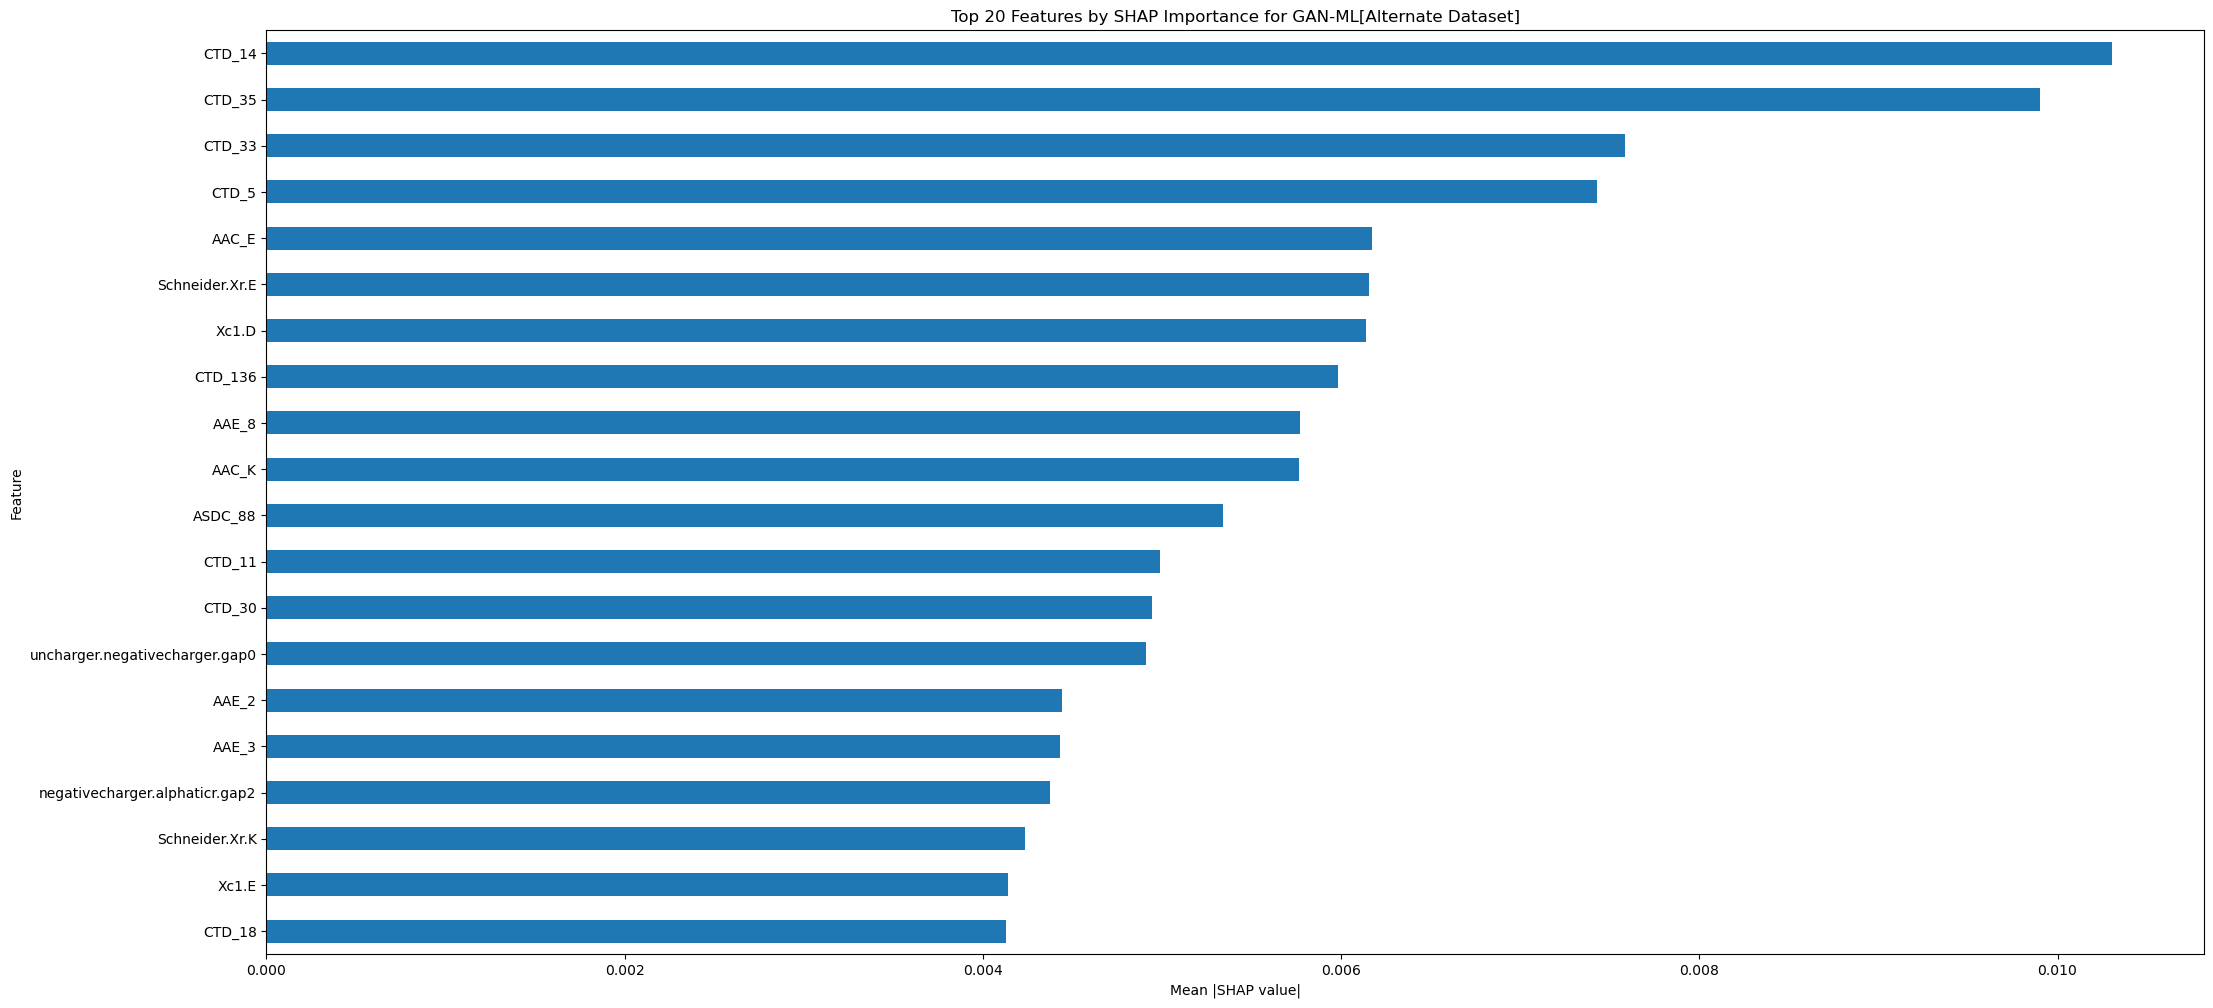

In [16]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier

# Assuming 'ExtraTreesClassifier()' is present in ml list
# Fit the Extra Trees model
et_model = ExtraTreesClassifier(random_state=seed)
et_model.fit(X_train, y_train)

# Calculate SHAP values
explainer = shap.Explainer(et_model, X_train)
shap_values = explainer(X_train)

# Check the shape of shap_values.values
print(shap_values.values.shape)

# If shap_values.values has 3 dimensions, it indicates multi-output
# For binary classification, select values for the positive class (index 1)
if shap_values.values.ndim == 3:
    shap_values_selected = shap_values.values[:, :, 1]  # Select the positive class
else:
    shap_values_selected = shap_values.values

# Get the SHAP values for the selected output (for binary classification or regression)
shap_values_df = pd.DataFrame(shap_values_selected, columns=fea)

# Calculate mean absolute SHAP values for each feature
mean_shap_values = shap_values_df.abs().mean().sort_values(ascending=False)

# Get the top 20 features
top_20_features = mean_shap_values.head(20)

# Plot the top 20 features
plt.figure(figsize=(25, 12))
top_20_features.plot(kind='barh')
plt.title('Top 20 Features by SHAP Importance for GAN-ML[Alternate Dataset]')
plt.xlabel('Mean |SHAP value|')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.savefig('top_20_features_shap_importance_alternate.pdf', format='pdf', dpi=300)
plt.show()

In [17]:
#ALL_eval_test

process_DT
process_ET


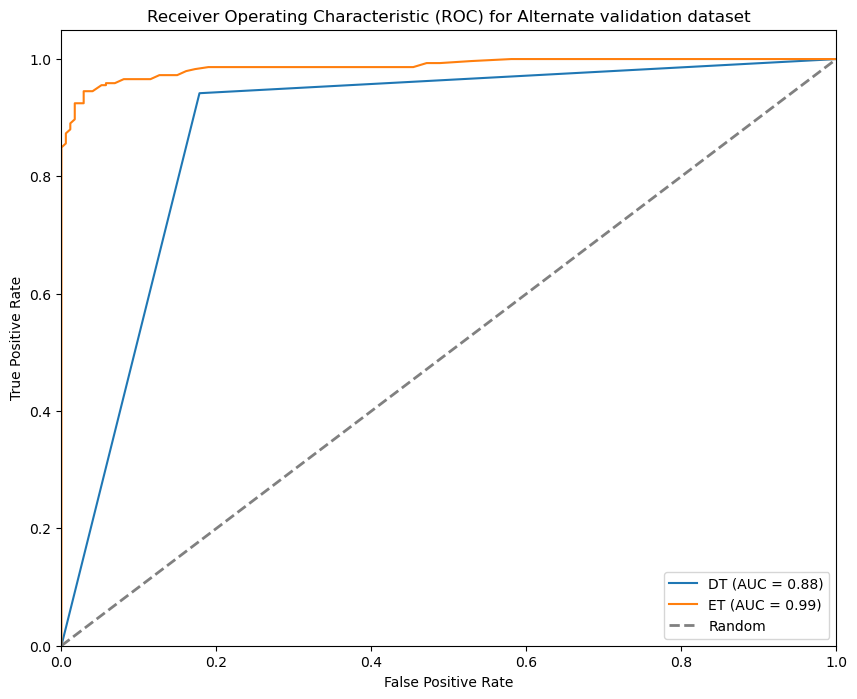

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming ml is a list of model names, X_train, X_test, y_train, y_test are your data
index = []
ALL_eval_test = pd.DataFrame()
plt.figure(figsize=(10, 8))

for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train, y_train)

    # Assuming evaluate returns predicted probabilities for each class
    y_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})')

    # Store other evaluation metrics if needed
    eval_dictionary = {'AUC': roc_auc}
    eval_dict = eval_dict + [eval_dictionary]

    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test, Evals], axis=1)
    index.append("{}".format(i))

ALL_eval_test.columns = index

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', color='gray', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Alternate validation dataset')
plt.legend(loc="lower right")
plt.show()

process_DT
process_ET


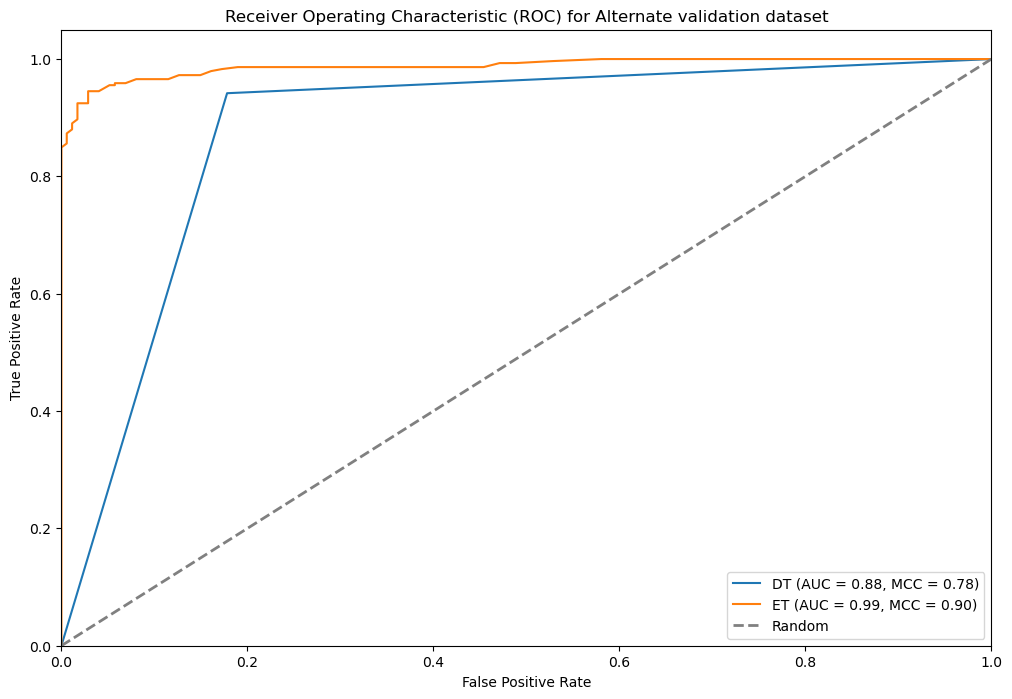

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, matthews_corrcoef

# Assuming ml is a list of model names, X_train, X_test, y_train, y_test are your data
index = []
ALL_eval_test = pd.DataFrame()
plt.figure(figsize=(12, 8))

for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train, y_train)

    # Assuming evaluate returns predicted probabilities for each class
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # MCC Calculation
    y_pred = model.predict(X_test)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Plot the ROC curve
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f}, MCC = {mcc:.2f})')

    # Store other evaluation metrics if needed
    eval_dictionary = {'AUC': roc_auc, 'MCC': mcc}
    eval_dict = eval_dict + [eval_dictionary]

    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test, Evals], axis=1)
    index.append("{}".format(i))

ALL_eval_test.columns = index

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', color='gray', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Alternate validation dataset')
plt.legend(loc="lower right")
plt.show()

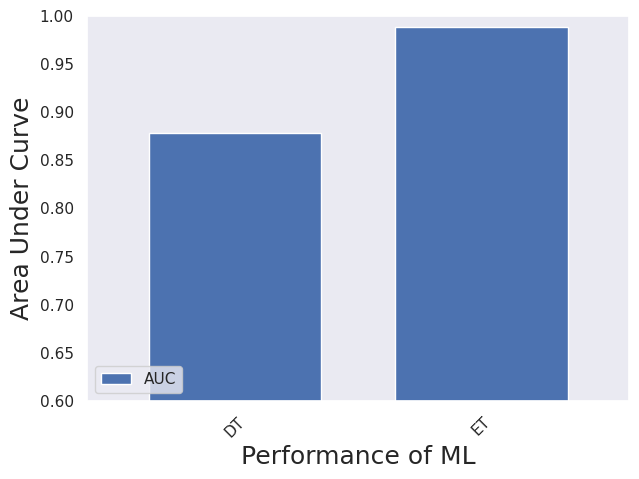

In [20]:
evals = ALL_eval.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

In [21]:
ALL_eval_test

,DT,ET
AUC,0.881810,0.987472
MCC,0.777898,0.901826


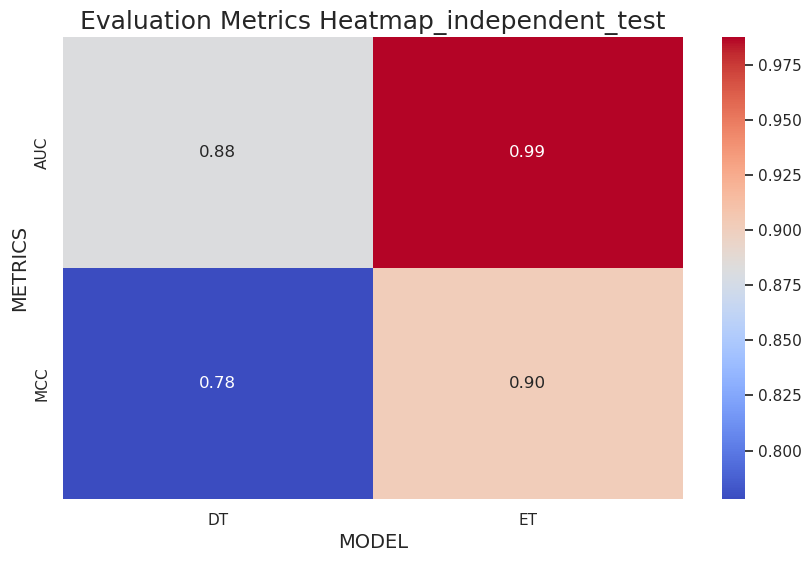

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ALL_eval_test is a DataFrame with metrics as columns and models as rows

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ALL_eval_test, cmap='coolwarm', annot=True, fmt=".2f", cbar=True)

plt.title('Evaluation Metrics Heatmap_independent_test', fontsize=18)
plt.xlabel('MODEL', fontsize=14)
plt.ylabel('METRICS',size=14)

plt.show()

In [23]:
# this is a code for evaluation >>effects after data normalization and standarization </h1>
#Scaling the train and test dataset for training
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
nms = MinMaxScaler()
X_train_norm = nms.fit_transform(X_train)
X_test_norm = nms.transform(X_test)
#standarization
stdsc = StandardScaler(with_mean=False)
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

In [24]:
#Save the standarzied and normalixed data
X_train_norm1 = pd.DataFrame(X_train_norm)
X_train_norm1.to_csv('data/train/X_train_norm.csv',index=False)
X_test_norm1 = pd.DataFrame(X_test_norm)
X_test_norm1.to_csv('data/test/X_test_norm.csv',index=False)
#standarization
X_train_std1 = pd.DataFrame(X_train_std)
X_train_std1.to_csv('data/train/X_train_std.csv',index=False)
X_test_std1 = pd.DataFrame(X_test_std)
X_test_std1.to_csv('data/test/X_test_std.csv',index=False)

In [25]:
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train_norm,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_ET


In [26]:
ALL_eval

,DT,ET
ACC,0.888710,0.940323
F1,0.911905,0.951509
F2,0.916256,0.941460
GMean,0.877007,0.942152
SEN,0.919280,0.934920
PREC,0.905131,0.968931
SPEC,0.837321,0.949600
MCC,0.761352,0.875075
AUC,0.878301,0.987816
AUPR,0.882575,0.993290


In [27]:
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train_std,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_ET


In [28]:
#FIVE-FOLD RESULT FOR TRAINING DATASET
ALL_eval

,DT,ET
ACC,0.888710,0.940323
F1,0.911905,0.951509
F2,0.916256,0.941460
GMean,0.877007,0.942152
SEN,0.919280,0.934920
PREC,0.905131,0.968931
SPEC,0.837321,0.949600
MCC,0.761352,0.875075
AUC,0.878301,0.987816
AUPR,0.882575,0.993290


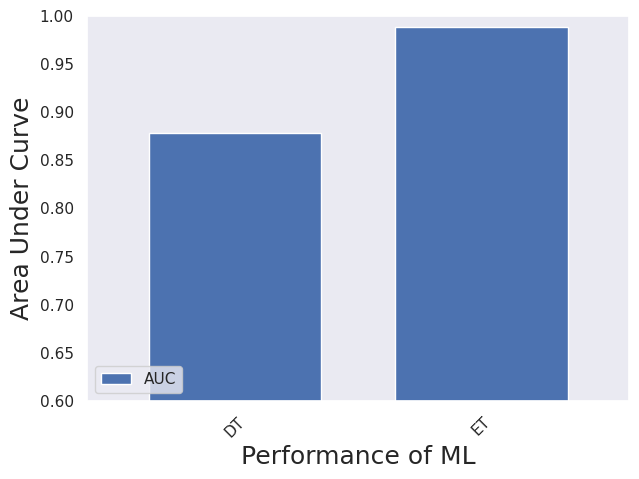

In [29]:
evals = ALL_eval.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

In [30]:
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train_norm,y_train)
    eval_dictionary = evaluate(X_test_norm,y_test,model)
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

process_DT
process_ET


In [31]:
ALL_eval_test

,DT,ET
ACC,0.896996,0.952790
F1,0.919732,0.961538
F2,0.932836,0.949586
GMean,0.879768,0.956409
SEN,0.941781,0.941781
PREC,0.898693,0.982143
SPEC,0.821839,0.971264
MCC,0.777898,0.901826
AUC,0.881810,0.987472
AUPR,0.882852,0.993268


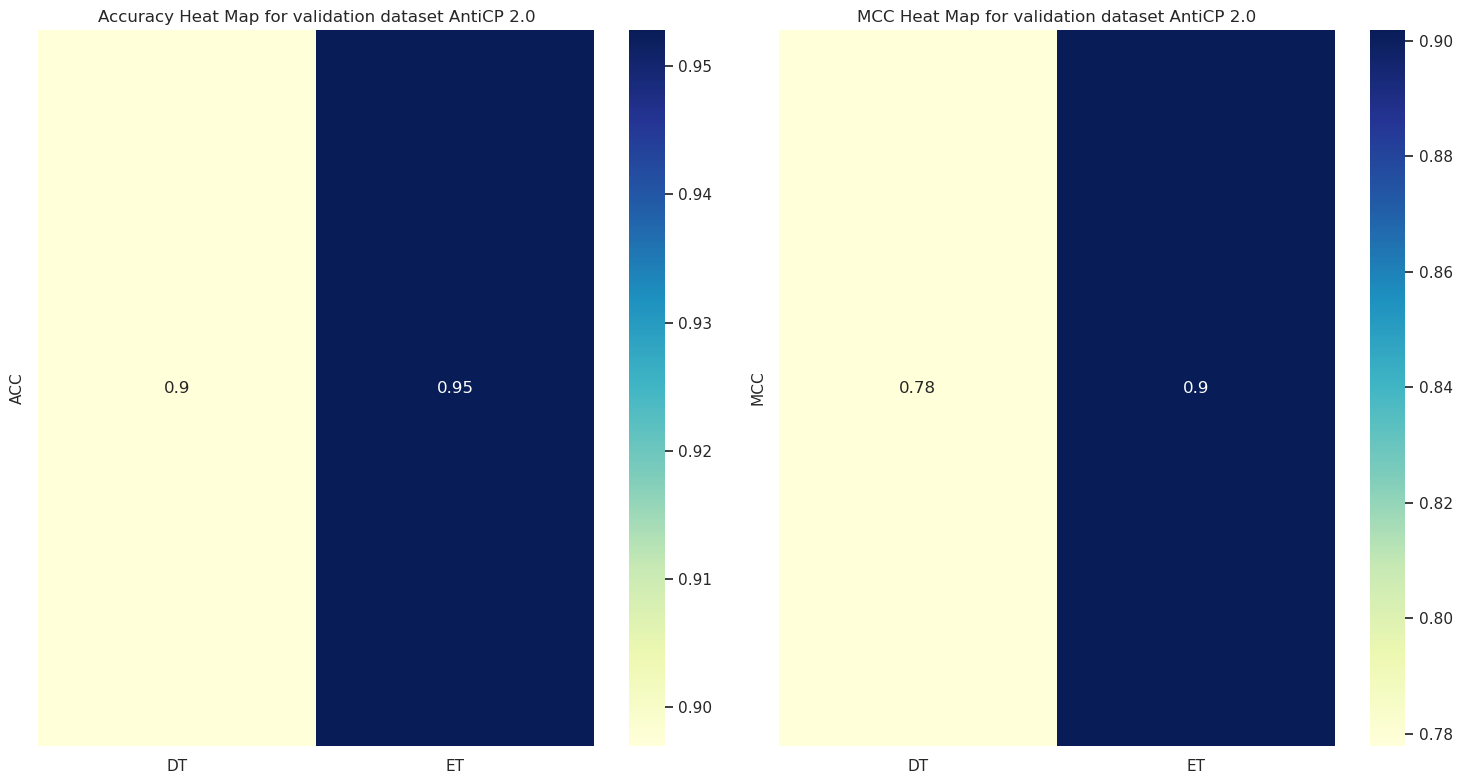

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ALL_eval_test contains accuracy and MCC values for different models

# Generate a heat map for accuracy and MCC side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Accuracy Heat Map
sns.heatmap(ALL_eval_test.loc[['ACC']], annot=True, cmap="YlGnBu", ax=axes[0])
axes[0].set_title('Accuracy Heat Map for validation dataset AntiCP 2.0')

# MCC Heat Map
sns.heatmap(ALL_eval_test.loc[['MCC']], annot=True, cmap="YlGnBu", ax=axes[1])
axes[1].set_title('MCC Heat Map for validation dataset AntiCP 2.0')

plt.tight_layout()
plt.show()

In [33]:
ALL_eval_test

,DT,ET
ACC,0.896996,0.952790
F1,0.919732,0.961538
F2,0.932836,0.949586
GMean,0.879768,0.956409
SEN,0.941781,0.941781
PREC,0.898693,0.982143
SPEC,0.821839,0.971264
MCC,0.777898,0.901826
AUC,0.881810,0.987472
AUPR,0.882852,0.993268
